# Projeto Final
## Modelagem e Análise de Rotas Urbanas com Grafos
### Cidade: Natal, Rio Grande do Norte — Brasil

**Disciplina:** Algoritmos e Estrutura de Dados II  
**Aluno:** _José Alex Araujo de Santana_

---

### Problema
Dado:
- Ponto de **origem A** (onde o usuário está);
- Ponto de **destino B** (onde quer chegar);
- **Distância máxima de caminhada X** (metros);

Encontrar o melhor **ponto de embarque P** (a ≤ X metros de A), tal que a rota total seja otimizada:

```
A ──(caminhada)──► P ──(carro)──► B
```

### Cenários comparados
1. Menor rota em **distância** (metros);
2. Rota mais rápida **sem trânsito**;
3. Rota mais rápida **com trânsito sintético**;
4. Caso **sem caminhada** (A → B direto de carro);
5. **Ganho** ao caminhar até outro ponto de embarque.


---
## Seção 1 — Instalação e Importações

In [1]:
# Execute esta célula apenas uma vez no Colab
!pip install osmnx folium matplotlib networkx numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.5 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import math
import heapq
import time
import warnings
from collections import defaultdict

warnings.filterwarnings('ignore')

# Configurações de plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print(f"osmnx   : {ox.__version__}")
print(f"networkx: {nx.__version__}")
print(f"folium  : {folium.__version__}")
print("Ambiente pronto!")

osmnx   : 2.1.0
networkx: 3.6.1
folium  : 0.20.0
Ambiente pronto!


---
## Seção 2 — Modelagem do Grafo Urbano

### Como o problema foi modelado como grafo?

A rede viária de Natal-RN é representada como um **dígrafo ponderado** `G = (V, E, w)`:

| Componente | Representação | Exemplo |
|---|---|---|
| **Nó** | Cruzamento ou ponto de interesse | Interseção de ruas |
| **Aresta** | Trecho de via entre dois cruzamentos | Segmento da Av. Salgado Filho |
| **Peso `length`** | Comprimento em metros | 450 m |
| **Peso `travel_time`** | Tempo de travessia sem trânsito (s) | 27 s |
| **Peso `travel_time_traffic`** | Tempo com trânsito sintético (s) | 54 s |

O grafo é **direcionado** porque ruas podem ser de mão única. Cada aresta também carrega o atributo `highway` (tipo de via), que define o fator de congestionamento no trânsito sintético.

> **Fonte dos dados:** OpenStreetMap, via biblioteca OSMnx.

In [3]:
# ============================================================
# DOWNLOAD DO GRAFO REAL DE NATAL-RN
# ============================================================
# Usamos network_type='drive' para obter apenas vias de carro.
# simplify=True funde nós intermediários (melhora performance).
# retain_all=False remove nós isolados.

print("Baixando grafo viário de Natal-RN (pode levar ~1 minuto)...")
t0 = time.time()

G = ox.graph_from_place(
    "Natal, Rio Grande do Norte, Brazil",
    network_type="drive",
    simplify=True,
    retain_all=False
)

t1 = time.time()
print(f"Grafo baixado em {t1-t0:.1f}s")
print(f"Nós (cruzamentos) : {G.number_of_nodes():,}")
print(f"Arestas (vias)    : {G.number_of_edges():,}")
print(f"Grafo dirigido    : {G.is_directed()}")

Baixando grafo viário de Natal-RN (pode levar ~1 minuto)...
Grafo baixado em 19.7s
Nós (cruzamentos) : 18,578
Arestas (vias)    : 48,183
Grafo dirigido    : True


In [4]:
# Inspecionar atributos reais do grafo
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

print("=== Atributos dos NÓS ===")
print(nodes_gdf.columns.tolist())
print(nodes_gdf.head(3))

print("\n=== Atributos das ARESTAS ===")
print(edges_gdf.columns.tolist())
print(edges_gdf[['length','highway','maxspeed','name']].head(5))

print("\n=== Tipos de via presentes ===")
# highway pode ser lista ou string
highways = edges_gdf['highway'].explode().value_counts()
print(highways.head(10))

=== Atributos dos NÓS ===
['y', 'x', 'street_count', 'highway', 'railway', 'junction', 'geometry']
                  y          x  street_count highway railway junction  \
osmid                                                                   
243207469 -5.831500 -35.183132             3     NaN     NaN      NaN   
243207479 -5.823197 -35.183370             3     NaN     NaN      NaN   
243207483 -5.816928 -35.183197             3     NaN     NaN      NaN   

                            geometry  
osmid                                 
243207469  POINT (-35.18313 -5.8315)  
243207479  POINT (-35.18337 -5.8232)  
243207483  POINT (-35.1832 -5.81693)  

=== Atributos das ARESTAS ===
['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'ref', 'reversed', 'length', 'geometry', 'bridge', 'junction', 'access', 'tunnel', 'width']
                             length    highway maxspeed  \
u         v          key                                  
243207469 7051202996 0     6.494295    

In [5]:
# ============================================================
# PASSO 1: Adicionar velocidades padrão onde maxspeed é nulo
# ============================================================
# O OSMnx já provê ox.add_edge_speeds() que preenche maxspeed
# com valores padrão por tipo de via (fallback_speed).

G = ox.add_edge_speeds(G)          # preenche 'speed_kph'
G = ox.add_edge_travel_times(G)    # calcula 'travel_time' = length / speed

print("Velocidades e tempos de viagem adicionados.")

# Conferir
sample_edge = list(G.edges(data=True))[0]
print("\nExemplo de aresta com todos os pesos:")
for k, v in sample_edge[2].items():
    print(f"  {k}: {v}")

Velocidades e tempos de viagem adicionados.

Exemplo de aresta com todos os pesos:
  osmid: 301945481
  highway: primary
  lanes: 2
  maxspeed: 70
  name: Avenida Senador Dinarte de Medeiros Mariz
  oneway: True
  ref: RN-301
  reversed: False
  length: 6.494295466532696
  speed_kph: 70.0
  travel_time: 0.33399233827882435


In [41]:
# ============================================================
# PASSO 2: Trânsito sintético — fator de congestionamento
# ============================================================
#
# Modelagem: cada tipo de via recebe um multiplicador que simula
# o congestionamento típico em horário de pico.
#
# Justificativa dos fatores:
#   - motorway/trunk: velocidade alta, mas gargalos em entradas/saídas → fator 2.2-2.5
#   - primary: avenidas principais com semáforos → fator 2.0
#   - secondary: vias intermediárias → fator 1.7
#   - residential: pouco tráfego → fator 1.1
#
# travel_time_traffic = travel_time * fator

TRAFFIC_FACTORS = {
    'motorway'    : 2.5,
    'trunk'       : 2.2,
    'primary'     : 2.0,
    'secondary'   : 1.7,
    'tertiary'    : 1.4,
    'residential' : 1.1,
    'living_street': 1.0,
    'unclassified': 1.2,
    'service'     : 1.0,
}

for u, v, k, data in G.edges(keys=True, data=True):
    highway = data.get('highway', 'unclassified')
    # highway pode ser lista no OSM; pegar o primeiro
    if isinstance(highway, list):
        highway = highway[0]
    # remover sufixos como '_link'
    highway_base = highway.replace('_link', '').strip()
    factor = TRAFFIC_FACTORS.get(highway_base, 1.3)
    tt = data.get('travel_time', data.get('length', 100) / 8.33)
    G[u][v][k]['travel_time_traffic'] = round(tt * factor, 4)
    G[u][v][k]['congestion_factor']   = factor

print("Trânsito sintético adicionado!")
print("\nFatores utilizados:")
for via, fator in TRAFFIC_FACTORS.items():
    print(f"  {via:<20}: x{fator}")

Trânsito sintético adicionado!

Fatores utilizados:
  motorway            : x2.5
  trunk               : x2.2
  primary             : x2.0
  secondary           : x1.7
  tertiary            : x1.4
  residential         : x1.1
  living_street       : x1.0
  unclassified        : x1.2
  service             : x1.0


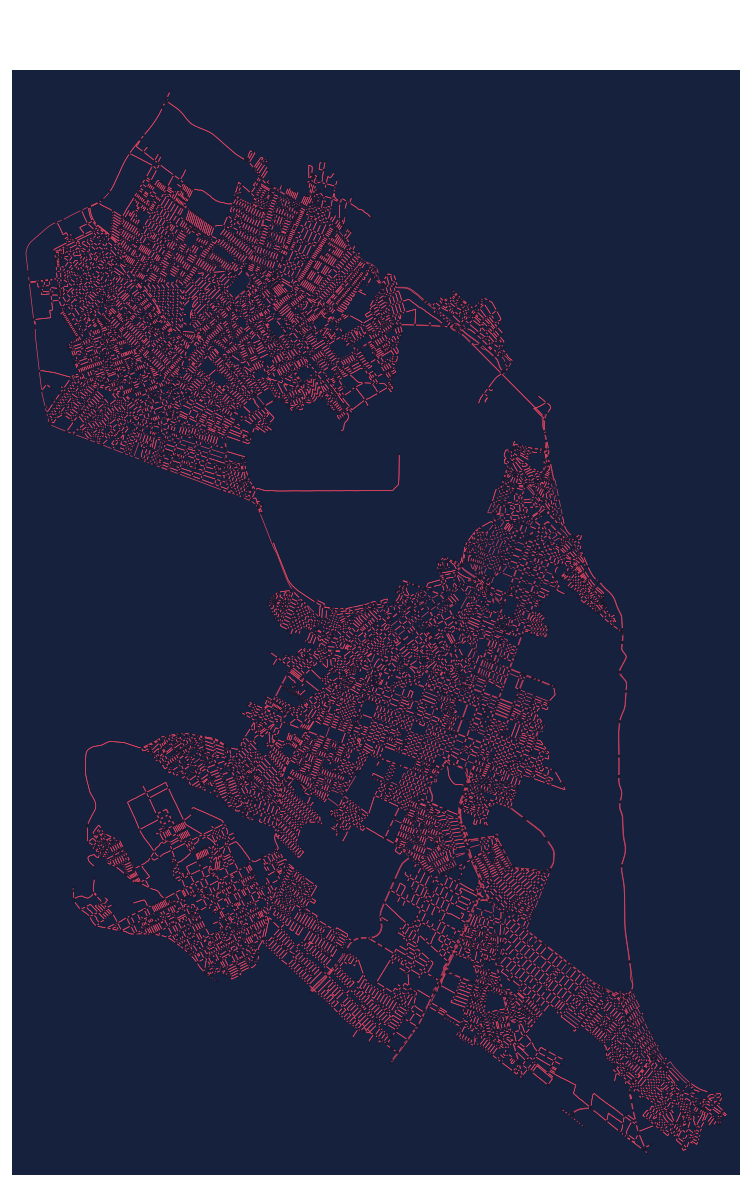

Grafo com 18,578 nós e 48,183 arestas


In [8]:
# ============================================================
# Visualização do grafo de Natal-RN
# ============================================================
fig, ax = ox.plot_graph(
    G,
    figsize=(12, 10),
    node_size=2,
    node_color='#1a1a2e',
    edge_color='#e94560',
    edge_linewidth=0.4,
    bgcolor='#16213e',
    show=False,
    close=False
)
ax.set_title("Rede Viária de Natal-RN\n(grafo dirigido — apenas vias de carro)",
             color='white', fontsize=13, pad=12)
plt.tight_layout()
plt.show()
print(f"Grafo com {G.number_of_nodes():,} nós e {G.number_of_edges():,} arestas")

---
## Seção 3 — Definição dos Pontos A, B e X

### Locais escolhidos para o experimento:

| Ponto | Local | Coordenadas |
|---|---|---|
| **A (Origem)** | UFRN — Campus Central | -5.8363, -35.1974 |
| **B (Destino)** | Ponta Negra — Natal Shopping | -5.8779, -35.1972 |
| **X (Caminhada)** | 500 metros | — |

> Esses pontos podem ser alterados livremente para outros locais de Natal.

In [80]:
# ============================================================
# PONTOS DE ORIGEM, DESTINO E RAIO DE CAMINHADA
# ============================================================

# A — Origem
LAT_A, LON_A = -5.8363, -35.1974

# B — Destino
LAT_B, LON_B = -5.8416, -35.2102

# X — Distância máxima de caminhada (metros)
X_MAX = 500

# Velocidade de caminhada média (m/s) — 5 km/h
VELOCIDADE_CAMINHADA = 1.39

# Encontrar os nós mais próximos no grafo
NO_A = ox.nearest_nodes(G, LON_A, LAT_A)
NO_B = ox.nearest_nodes(G, LON_B, LAT_B)

print(f"Ponto A (Origem)  : nó {NO_A}")
print(f"  Coord grafo     : lat={G.nodes[NO_A]['y']:.6f}, lon={G.nodes[NO_A]['x']:.6f}")
print(f"Ponto B (Destino) : nó {NO_B}")
print(f"  Coord grafo     : lat={G.nodes[NO_B]['y']:.6f}, lon={G.nodes[NO_B]['x']:.6f}")
print(f"Raio de caminhada : {X_MAX} m")

Ponto A (Origem)  : nó 1387156176
  Coord grafo     : lat=-5.838072, lon=-35.196665
Ponto B (Destino) : nó 501834747
  Coord grafo     : lat=-5.841800, lon=-35.209926
Raio de caminhada : 500 m


In [81]:
# ============================================================
# FUNÇÃO AUXILIAR: distância geográfica (Haversine)
# ============================================================
# Usada como heurística do A* e para calcular distâncias de caminhada.
# A fórmula de Haversine calcula a distância entre dois pontos na
# superfície de uma esfera (Terra) a partir de latitude e longitude.

def haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """
    Calcula a distância em linha reta (metros) entre dois pontos
    geográficos usando a fórmula de Haversine.

    Parâmetros
    ----------
    lat1, lon1 : coordenadas do ponto 1 (graus decimais)
    lat2, lon2 : coordenadas do ponto 2 (graus decimais)

    Retorna
    -------
    Distância em metros
    """
    R = 6_371_009  # raio médio da Terra em metros
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi    = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = (math.sin(delta_phi / 2) ** 2
         + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2)
    return 2 * R * math.asin(math.sqrt(a))

# Teste rápido
d_ab = haversine(LAT_A, LON_A, LAT_B, LON_B)
print(f"Distância em linha reta A→B: {d_ab:.0f} m  ({d_ab/1000:.2f} km)")

Distância em linha reta A→B: 1534 m  (1.53 km)


In [82]:
# ============================================================
# FILTRAGEM DOS CANDIDATOS P
# ============================================================
# Um nó é candidato a ponto de embarque P se:
#   1. Não é A nem B
#   2. Está a no máximo X_MAX metros (em linha reta) de A
#
# Usamos distância em linha reta como filtro inicial (mais rápido).
# A distância real pelo grafo seria mais precisa, mas muito mais lenta.

lat_a = G.nodes[NO_A]['y']
lon_a = G.nodes[NO_A]['x']

candidatos_P = []  # lista de (node_id, dist_caminhada_metros)

for node_id in G.nodes():
    if node_id in (NO_A, NO_B):
        continue
    lat_n = G.nodes[node_id]['y']
    lon_n = G.nodes[node_id]['x']
    dist = haversine(lat_a, lon_a, lat_n, lon_n)
    if dist <= X_MAX:
        candidatos_P.append((node_id, dist))

# Ordenar por distância de caminhada
candidatos_P.sort(key=lambda x: x[1])

print(f"Total de candidatos P (≤ {X_MAX}m de A): {len(candidatos_P)}")
print(f"\nTop 10 candidatos (mais próximos de A):")
for i, (nid, dist) in enumerate(candidatos_P[:10]):
    t_walk = dist / VELOCIDADE_CAMINHADA
    print(f"  {i+1:2}. nó {nid:8} | dist={dist:6.0f}m | t_caminhada={t_walk:.0f}s")

Total de candidatos P (≤ 500m de A): 3

Top 10 candidatos (mais próximos de A):
   1. nó 1387156168 | dist=    27m | t_caminhada=19s
   2. nó 1387156245 | dist=    39m | t_caminhada=28s
   3. nó 1387156244 | dist=    67m | t_caminhada=48s


---
## Seção 4 — Implementação dos Algoritmos

### Visão geral dos algoritmos

| Algoritmo | Complexidade | Estrutura de dados | Heurística |
|---|---|---|---|
| Dijkstra Simples | O(V²) | Lista linear | Não |
| Dijkstra com Heap | O((V+E) log V) | Fila de prioridade (min-heap) | Não |
| A* | O(E log V) | Min-heap | Sim (Haversine) |
| Bellman-Ford | O(V·E) | Relaxamento iterativo | Não |

Todos retornam: **(caminho, custo_total, nós_expandidos)**


In [83]:
# ============================================================
# FUNÇÕES AUXILIARES COMPARTILHADAS
# ============================================================

def get_min_edge_weight(G: nx.MultiDiGraph, u: int, v: int, peso: str) -> float:
    """
    Para multigrafos (MultiDiGraph), pode haver múltiplas arestas entre
    dois nós. Retorna o menor peso entre elas.
    """
    return min(
        data.get(peso, math.inf)
        for data in G[u][v].values()
    )


def reconstruir_caminho(anterior: dict, origem: int, destino: int) -> list:
    """
    Reconstrói o caminho percorrido a partir do dicionário de predecessores.
    Retorna lista de nós do origem ao destino.
    """
    caminho = []
    no = destino
    while no in anterior:
        caminho.append(no)
        no = anterior[no]
    if no == origem:
        caminho.append(origem)
    caminho.reverse()
    if not caminho or caminho[0] != origem:
        return []  # caminho não encontrado
    return caminho


def custo_caminho(G: nx.MultiDiGraph, caminho: list, peso: str) -> float:
    """Soma os pesos de todas as arestas de um caminho."""
    if len(caminho) < 2:
        return 0.0
    return sum(
        get_min_edge_weight(G, caminho[i], caminho[i+1], peso)
        for i in range(len(caminho) - 1)
    )


print("Funções auxiliares definidas.")

Funções auxiliares definidas.


In [84]:
# ============================================================
# ALGORITMO 1: DIJKSTRA SIMPLES
# ============================================================
# Implementação clássica com busca linear do mínimo.
# Complexidade: O(V²) — ineficiente para grafos grandes.
#
# Funcionamento:
#   1. Inicializa dist[v] = ∞ para todos os nós, dist[origem] = 0
#   2. A cada passo, escolhe o nó u não visitado com menor dist[u] (busca linear)
#   3. Para cada vizinho v de u: se dist[u] + w(u,v) < dist[v], atualiza dist[v]
#   4. Repete até alcançar o destino

def dijkstra_simples(
    G: nx.MultiDiGraph,
    origem: int,
    destino: int,
    peso: str = 'length'
) -> tuple[list, float, int]:
    """
    Dijkstra com busca linear do mínimo (sem heap).

    Retorna
    -------
    caminho      : lista de nós do origem ao destino
    custo_total  : custo mínimo encontrado
    nos_expandidos : número de nós processados
    """
    todos_nos  = list(G.nodes())
    dist       = {n: math.inf for n in todos_nos}
    dist[origem] = 0.0
    anterior   = {}
    visitados  = set()
    nos_exp    = 0

    while True:
        # Busca linear: O(V) por iteração → O(V²) no total
        u = None
        for n in todos_nos:
            if n not in visitados:
                if u is None or dist[n] < dist[u]:
                    u = n

        if u is None or dist[u] == math.inf:
            break  # grafo desconexo
        if u == destino:
            break  # chegamos

        visitados.add(u)
        nos_exp += 1

        for v in G.successors(u):
            if v in visitados:
                continue
            w = get_min_edge_weight(G, u, v, peso)
            nova_dist = dist[u] + w
            if nova_dist < dist[v]:
                dist[v]     = nova_dist
                anterior[v] = u

    caminho = reconstruir_caminho(anterior, origem, destino)
    return caminho, dist[destino], nos_exp


print("Dijkstra Simples definido.")

Dijkstra Simples definido.


In [85]:
# ============================================================
# ALGORITMO 2: DIJKSTRA COM HEAP (FILA DE PRIORIDADE)
# ============================================================
# Usa um min-heap para encontrar o nó de menor distância em O(log V).
# Complexidade total: O((V + E) log V) — muito mais eficiente.
#
# Diferença-chave em relação ao Dijkstra Simples:
#   A busca pelo mínimo cai de O(V) para O(log V) graças ao heap.
#   Em grafos grandes (como Natal com milhares de nós), a diferença
#   de tempo de execução é enorme.

def dijkstra_heap(
    G: nx.MultiDiGraph,
    origem: int,
    destino: int,
    peso: str = 'length'
) -> tuple[list, float, int]:
    """
    Dijkstra com fila de prioridade (min-heap via heapq).

    Retorna
    -------
    caminho      : lista de nós do origem ao destino
    custo_total  : custo mínimo encontrado
    nos_expandidos : número de nós processados
    """
    dist       = {n: math.inf for n in G.nodes()}
    dist[origem] = 0.0
    anterior   = {}
    heap       = [(0.0, origem)]  # (dist, node)
    visitados  = set()
    nos_exp    = 0

    while heap:
        d, u = heapq.heappop(heap)  # O(log V)

        if u in visitados:
            continue  # versão lazy — ignora entradas antigas
        visitados.add(u)
        nos_exp += 1

        if u == destino:
            break

        for v in G.successors(u):
            if v in visitados:
                continue
            w = get_min_edge_weight(G, u, v, peso)
            nova_dist = dist[u] + w
            if nova_dist < dist[v]:
                dist[v]     = nova_dist
                anterior[v] = u
                heapq.heappush(heap, (nova_dist, v))  # O(log V)

    caminho = reconstruir_caminho(anterior, origem, destino)
    return caminho, dist[destino], nos_exp


print("Dijkstra com Heap definido.")

Dijkstra com Heap definido.


In [86]:
# ============================================================
# ALGORITMO 3: A* COM HEURÍSTICA GEOGRÁFICA
# ============================================================
# O A* adiciona uma heurística h(n) ao Dijkstra:
#   f(n) = g(n) + h(n)
#   g(n) = custo real do caminho percorrido até n
#   h(n) = estimativa do custo de n até o destino
#
# Heurística usada: distância Haversine (linha reta) entre n e B.
# É ADMISSÍVEL porque nunca superestima o custo real (linha reta ≤ caminho real).
# É CONSISTENTE (monótona): h(n) ≤ w(n, v) + h(v) para todo vizinho v.
#
# Resultado: expande MENOS nós que o Dijkstra porque guia a busca
# na direção do destino, descartando caminhos improváveis.

def astar(
    G: nx.MultiDiGraph,
    origem: int,
    destino: int,
    peso: str = 'length'
) -> tuple[list, float, int]:
    """
    A* com heurística geográfica (Haversine).

    A heurística usa a distância em linha reta entre cada nó e o destino.
    Para o peso 'travel_time' ou 'travel_time_traffic', a heurística
    é ajustada para unidades de tempo (dist / velocidade_maxima).

    Retorna
    -------
    caminho      : lista de nós do origem ao destino
    custo_total  : custo mínimo encontrado
    nos_expandidos : número de nós processados
    """
    lat_dest = G.nodes[destino]['y']
    lon_dest = G.nodes[destino]['x']

    # Velocidade máxima estimada para heurística de tempo (m/s)
    # 120 km/h = 33.33 m/s — garante que h(n) nunca superestime
    V_MAX = 33.33

    def heuristica(n: int) -> float:
        dist_linha_reta = haversine(
            G.nodes[n]['y'], G.nodes[n]['x'],
            lat_dest, lon_dest
        )
        if peso == 'length':
            return dist_linha_reta
        else:  # travel_time ou travel_time_traffic
            return dist_linha_reta / V_MAX

    g_cost   = {n: math.inf for n in G.nodes()}
    g_cost[origem] = 0.0
    anterior = {}
    heap     = [(heuristica(origem), 0.0, origem)]  # (f, g, node)
    visitados = set()
    nos_exp   = 0

    while heap:
        f, g, u = heapq.heappop(heap)

        if u in visitados:
            continue
        visitados.add(u)
        nos_exp += 1

        if u == destino:
            break

        for v in G.successors(u):
            if v in visitados:
                continue
            w    = get_min_edge_weight(G, u, v, peso)
            novo_g = g_cost[u] + w
            if novo_g < g_cost[v]:
                g_cost[v]   = novo_g
                anterior[v] = u
                f_v = novo_g + heuristica(v)
                heapq.heappush(heap, (f_v, novo_g, v))

    caminho = reconstruir_caminho(anterior, origem, destino)
    return caminho, g_cost[destino], nos_exp


print("A* Geográfico definido.")

A* Geográfico definido.


In [87]:
# ============================================================
# ALGORITMO 4: BELLMAN-FORD
# ============================================================
# Algoritmo clássico de relaxamento iterativo de arestas.
# Complexidade: O(V · E) — mais lento, mas mais versátil.
#
# Vantagens sobre Dijkstra:
#   - Funciona com pesos NEGATIVOS (útil para modelar bônus de via)
#   - Detecta ciclos negativos
#
# No nosso contexto: aplica-se bem se quisermos modelar, por exemplo,
# um desconto de tempo por usar uma ciclovia (peso negativo).
#
# Funcionamento:
#   Repete |V|-1 vezes: para cada aresta (u,v), se dist[u]+w < dist[v],
#   relaxa dist[v]. Converge porque um caminho mínimo tem no máximo |V|-1 arestas.

def bellman_ford(
    G: nx.MultiDiGraph,
    origem: int,
    destino: int,
    peso: str = 'length'
) -> tuple[list, float, int]:
    """
    Bellman-Ford com detecção antecipada de convergência.

    Retorna
    -------
    caminho      : lista de nós do origem ao destino
    custo_total  : custo mínimo encontrado
    iteracoes    : número de iterações realizadas (≤ V-1)
    """
    dist        = {n: math.inf for n in G.nodes()}
    dist[origem] = 0.0
    anterior    = {}
    iteracoes   = 0
    lista_arestas = list(G.edges(data=True))  # pré-computar

    for _ in range(len(G.nodes()) - 1):
        iteracoes += 1
        houve_atualizacao = False

        for u, v, data in lista_arestas:
            w = data.get(peso, math.inf)
            if dist[u] + w < dist[v]:
                dist[v]     = dist[u] + w
                anterior[v] = u
                houve_atualizacao = True

        # Otimização: parar cedo se não houve atualização
        if not houve_atualizacao:
            break

    caminho = reconstruir_caminho(anterior, origem, destino)
    return caminho, dist[destino], iteracoes


print("Bellman-Ford definido.")

# Dicionário central com todos os algoritmos
ALGORITMOS = {
    'Dijkstra Simples': dijkstra_simples,
    'Dijkstra Heap'   : dijkstra_heap,
    'A*'              : astar,
    'Bellman-Ford'    : bellman_ford,
}
print("Todos os 4 algoritmos prontos:", list(ALGORITMOS.keys()))

Bellman-Ford definido.
Todos os 4 algoritmos prontos: ['Dijkstra Simples', 'Dijkstra Heap', 'A*', 'Bellman-Ford']


---
## Seção 5 — Experimentos: Os 5 Cenários

In [88]:
# ============================================================
# CENÁRIO C4 — Sem caminhada: A → B direto de carro
# ============================================================
# Este é o caso base: o usuário não caminha, entra no carro
# diretamente de A e vai até B.

print("="*60)
print("CENÁRIO C4: Sem caminhada (A → B direto)")
print("="*60)

resultados_c4 = {}

for nome, func in ALGORITMOS.items():
    t_ini = time.perf_counter()
    cam, custo, exp = func(G, NO_A, NO_B, peso='length')
    t_fim = time.perf_counter()
    tempo_ms = (t_fim - t_ini) * 1000
    resultados_c4[nome] = {
        'caminho': cam, 'custo_m': custo,
        'nos_exp': exp, 'tempo_ms': tempo_ms
    }
    print(f"  {nome:<20} | dist={custo:8.0f}m | nós_exp={exp:5} | t={tempo_ms:.2f}ms")

CENÁRIO C4: Sem caminhada (A → B direto)
  Dijkstra Simples     | dist=    2629m | nós_exp=  773 | t=1469.26ms
  Dijkstra Heap        | dist=    2629m | nós_exp=  774 | t=7.79ms
  A*                   | dist=    2629m | nós_exp=  172 | t=3.69ms
  Bellman-Ford         | dist=    2629m | nós_exp=  116 | t=5237.14ms


In [89]:
# ============================================================
# CENÁRIOS C1, C2, C3 — Para cada P candidato
# ============================================================
# Para cada ponto de embarque P candidato:
#   C1: minimizar distância (P → B)
#   C2: minimizar tempo sem trânsito (P → B)
#   C3: minimizar tempo com trânsito (P → B)
#
# Testamos todos os 4 algoritmos em cada cenário.

CENARIOS_PESO = {
    'C1 - Distância'   : 'length',
    'C2 - Tempo'       : 'travel_time',
    'C3 - Trânsito'    : 'travel_time_traffic',
}

# Limitar a no máximo 20 candidatos para o Dijkstra Simples não
# travar em grafos grandes (pode ajustar conforme a máquina)
MAX_CANDIDATOS = 20
candidatos_limitados = candidatos_P[:MAX_CANDIDATOS]

# Estrutura: resultados[P][cenário][algoritmo] = {custo, nos_exp, tempo_ms}
resultados_completos = defaultdict(lambda: defaultdict(dict))

print(f"Rodando experimentos para {len(candidatos_limitados)} candidatos P...")
print("(Pode demorar alguns minutos para o Dijkstra Simples)\n")

for P, dist_walk in candidatos_limitados:
    for cen_nome, peso in CENARIOS_PESO.items():
        for alg_nome, func in ALGORITMOS.items():
            try:
                t0 = time.perf_counter()
                cam, custo, exp = func(G, P, NO_B, peso=peso)
                t1 = time.perf_counter()
                resultados_completos[P][cen_nome][alg_nome] = {
                    'caminho'  : cam,
                    'custo'    : custo,
                    'nos_exp'  : exp,
                    'tempo_ms' : (t1 - t0) * 1000,
                    'dist_walk': dist_walk,
                }
            except Exception as e:
                resultados_completos[P][cen_nome][alg_nome] = {'erro': str(e)}

print("Experimentos C1/C2/C3 concluídos!")

Rodando experimentos para 3 candidatos P...
(Pode demorar alguns minutos para o Dijkstra Simples)

Experimentos C1/C2/C3 concluídos!


In [90]:
# ============================================================
# CENÁRIO C5 — Ganho ao caminhar até outro P
# ============================================================
# Compara o custo total (caminhada + carro) de cada P versus
# não caminhar (partir de A direto).
# Métrica: tempo total = t_caminhada + t_carro (com trânsito)

print("="*60)
print("CENÁRIO C5: Ganho ao caminhar até outro P")
print("="*60)

# Tempo de A → B direto (sem caminhada, com trânsito)
_, t_sem_caminhar, _ = dijkstra_heap(G, NO_A, NO_B, peso='travel_time_traffic')
print(f"\nTempo sem caminhar (A→B): {t_sem_caminhar:.1f}s ({t_sem_caminhar/60:.1f} min)")
print(f"\n{'P':>8} | {'Caminhada':>10} | {'t_walk':>8} | {'t_carro':>10} | {'Total':>10} | {'Ganho':>10}")
print("-"*70)

resumo_c5 = []
for P, dist_walk in candidatos_limitados:
    t_walk = dist_walk / VELOCIDADE_CAMINHADA
    _, t_carro, _ = dijkstra_heap(G, P, NO_B, peso='travel_time_traffic')
    t_total = t_walk + t_carro
    ganho   = t_sem_caminhar - t_total
    resumo_c5.append((P, dist_walk, t_walk, t_carro, t_total, ganho))
    sinal = '+' if ganho > 0 else ''
    print(f"{P:>8} | {dist_walk:>8.0f}m | {t_walk:>6.0f}s | {t_carro:>8.0f}s | {t_total:>8.0f}s | {sinal}{ganho:.0f}s")

# Melhor P (maior ganho)
melhor_P = max(resumo_c5, key=lambda x: x[5])
print(f"\nMelhor ponto de embarque: nó {melhor_P[0]} "
      f"(caminhar {melhor_P[1]:.0f}m → ganho de {melhor_P[5]:.0f}s)")

CENÁRIO C5: Ganho ao caminhar até outro P

Tempo sem caminhar (A→B): 363.3s (6.1 min)

       P |  Caminhada |   t_walk |    t_carro |      Total |      Ganho
----------------------------------------------------------------------
1387156168 |       27m |     19s |      508s |      527s | -164s
1387156245 |       39m |     28s |      358s |      387s | -23s
1387156244 |       67m |     48s |      363s |      411s | -48s

Melhor ponto de embarque: nó 1387156245 (caminhar 39m → ganho de -23s)


---
## Seção 6 — Visualizações e Análise de Resultados

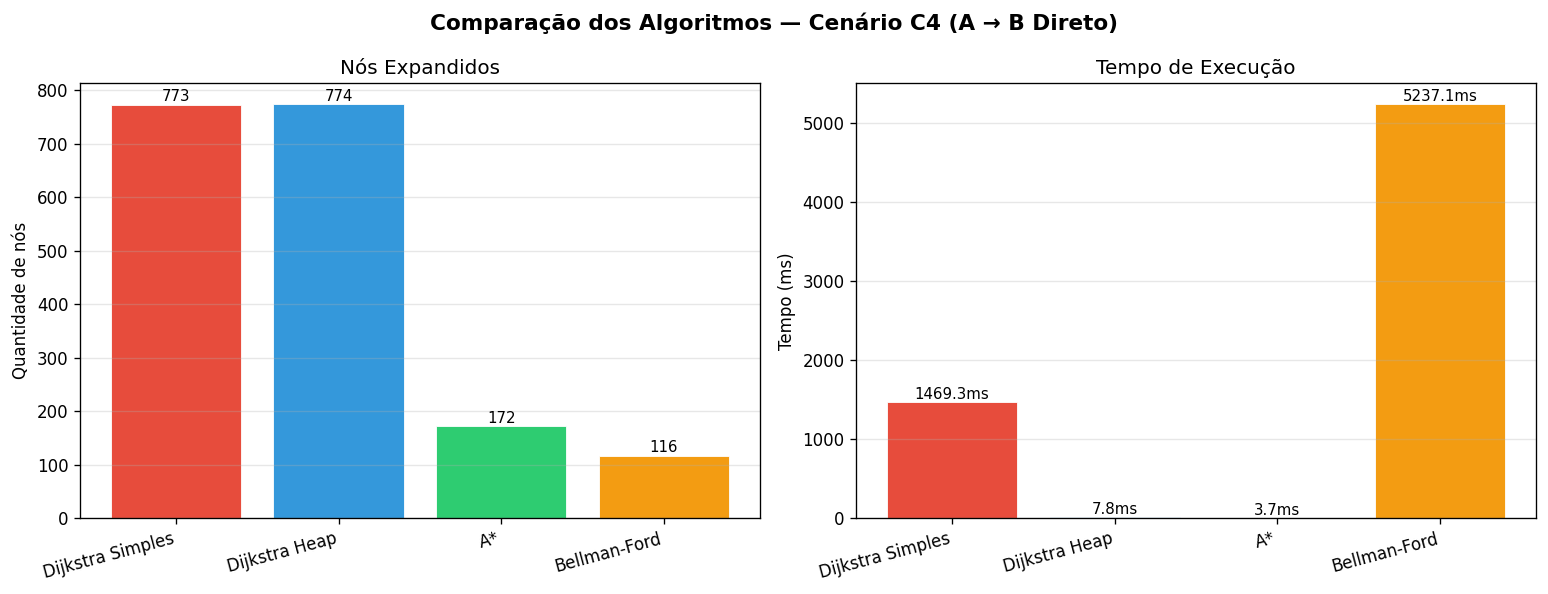

In [91]:
# ============================================================
# GRÁFICO 1: Comparação de nós expandidos por algoritmo (C4)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparação dos Algoritmos — Cenário C4 (A → B Direto)', fontsize=13, fontweight='bold')

nomes  = list(resultados_c4.keys())
nos    = [resultados_c4[n]['nos_exp']  for n in nomes]
tempos = [resultados_c4[n]['tempo_ms'] for n in nomes]
custos = [resultados_c4[n]['custo_m']  for n in nomes]

cores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Subplot 1: nós expandidos
ax1 = axes[0]
bars = ax1.bar(nomes, nos, color=cores, edgecolor='white', linewidth=0.5)
ax1.set_title('Nós Expandidos')
ax1.set_ylabel('Quantidade de nós')
ax1.set_xticklabels(nomes, rotation=15, ha='right')
for bar, val in zip(bars, nos):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:,}', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Subplot 2: tempo de execução
ax2 = axes[1]
bars2 = ax2.bar(nomes, tempos, color=cores, edgecolor='white', linewidth=0.5)
ax2.set_title('Tempo de Execução')
ax2.set_ylabel('Tempo (ms)')
ax2.set_xticklabels(nomes, rotation=15, ha='right')
for bar, val in zip(bars2, tempos):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.1f}ms', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

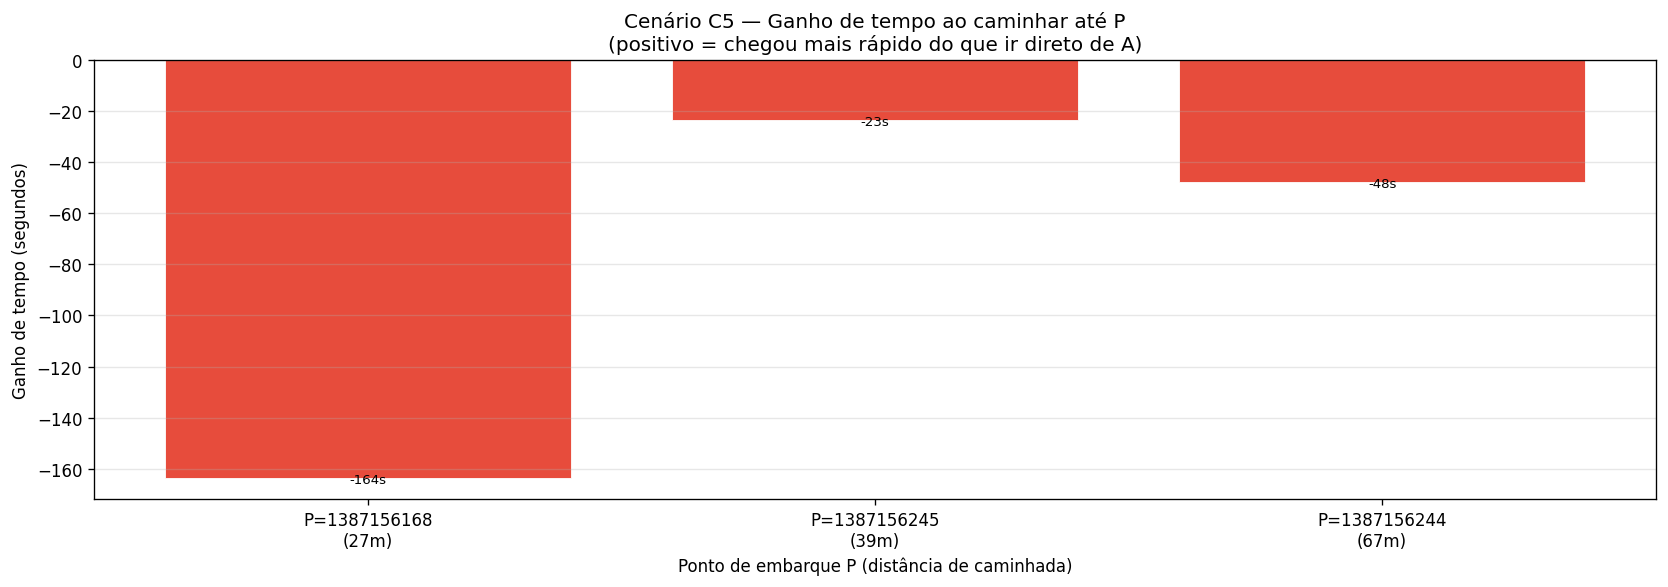

In [92]:
# ============================================================
# GRÁFICO 2: Ganho por ponto de embarque P (Cenário C5)
# ============================================================

# Usar apenas os 15 primeiros candidatos para o gráfico ficar legível
dados_plot = resumo_c5[:15]
labels  = [f"P={r[0]}\n({r[1]:.0f}m)" for r in dados_plot]
ganhos  = [r[5] for r in dados_plot]
totais  = [r[4] for r in dados_plot]

fig, ax = plt.subplots(figsize=(14, 5))
cores_ganho = ['#2ecc71' if g > 0 else '#e74c3c' for g in ganhos]
bars = ax.bar(labels, ganhos, color=cores_ganho, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=1, linestyle='--')
ax.set_title('Cenário C5 — Ganho de tempo ao caminhar até P\n'
             '(positivo = chegou mais rápido do que ir direto de A)', fontsize=12)
ax.set_ylabel('Ganho de tempo (segundos)')
ax.set_xlabel('Ponto de embarque P (distância de caminhada)')
for bar, val in zip(bars, ganhos):
    ypos = bar.get_height() + (1 if val >= 0 else -3)
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.0f}s', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

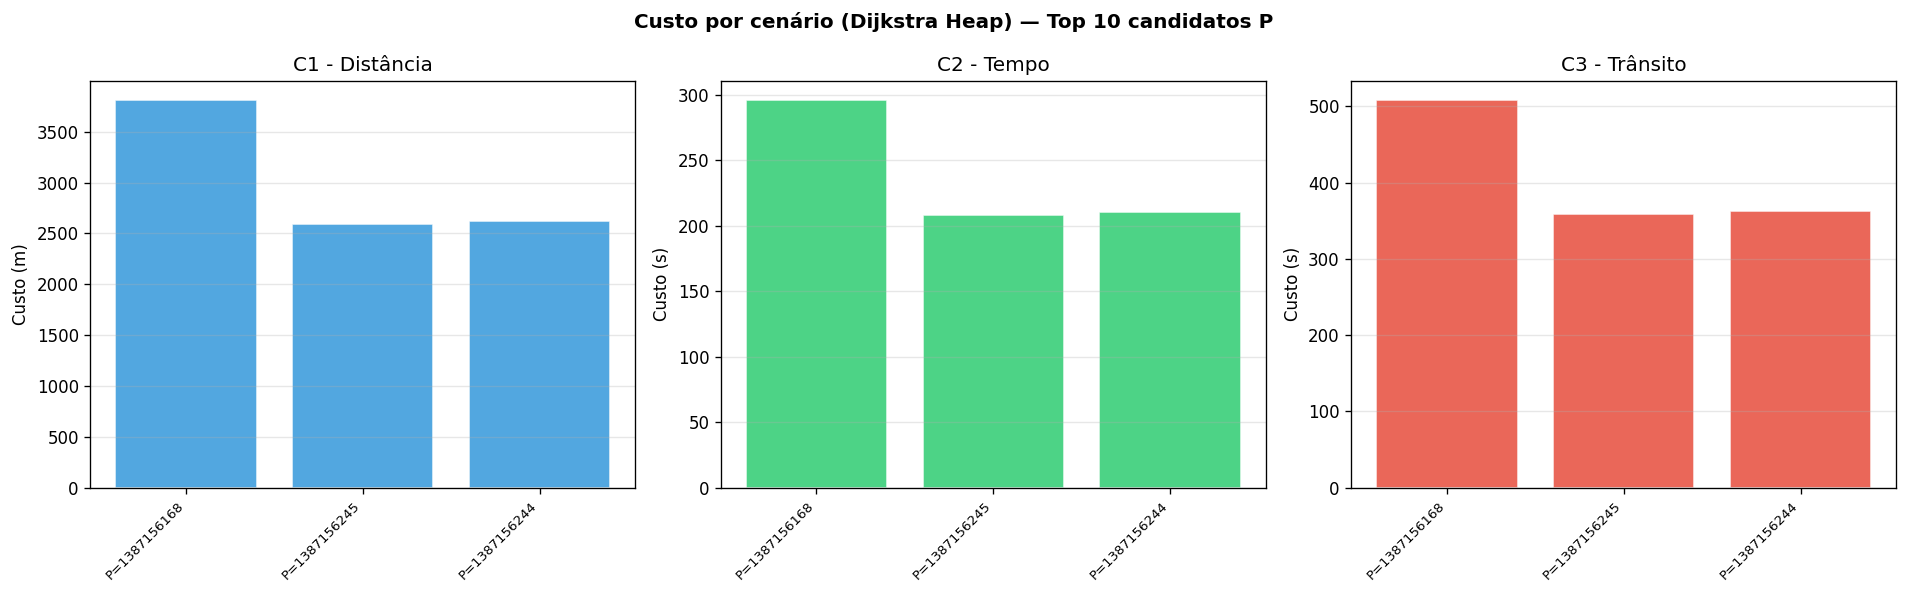

In [93]:
# ============================================================
# GRÁFICO 3: Comparação C1 vs C2 vs C3 para os top candidatos
# ============================================================
# Para cada candidato P, compara o custo nos 3 cenários usando Dijkstra Heap.

top_P = candidatos_limitados[:10]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Custo por cenário (Dijkstra Heap) — Top 10 candidatos P', fontsize=12, fontweight='bold')

cenarios_info = [
    ('C1 - Distância',  'length',               'm',  '#3498db'),
    ('C2 - Tempo',      'travel_time',           's',  '#2ecc71'),
    ('C3 - Trânsito',   'travel_time_traffic',   's',  '#e74c3c'),
]

for ax, (cen_nome, peso, unidade, cor) in zip(axes, cenarios_info):
    labels = [f"P={P}" for P, _ in top_P]
    custos = []
    for P, _ in top_P:
        try:
            c = resultados_completos[P][cen_nome]['Dijkstra Heap']['custo']
            custos.append(c)
        except (KeyError, TypeError):
            custos.append(0)
    bars = ax.bar(labels, custos, color=cor, edgecolor='white', alpha=0.85)
    ax.set_title(cen_nome)
    ax.set_ylabel(f'Custo ({unidade})')
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# MAPA INTERATIVO COM FOLIUM
# ============================================================
# Visualiza a rota do melhor P no mapa real de Natal-RN.

# Usar o melhor P do Cenário C5
P_MELHOR = melhor_P[0]

# Obter coordenadas
lat_a_g = G.nodes[NO_A]['y'];    lon_a_g = G.nodes[NO_A]['x']
lat_b_g = G.nodes[NO_B]['y'];    lon_b_g = G.nodes[NO_B]['x']
lat_p   = G.nodes[P_MELHOR]['y']; lon_p   = G.nodes[P_MELHOR]['x']

# Rota de carro: P → B (com trânsito)
rota_carro, _, _ = dijkstra_heap(G, P_MELHOR, NO_B, peso='travel_time_traffic')

# Coordenadas da rota de carro
coords_carro = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in rota_carro]

# Criar mapa centrado entre A e B
centro_lat = (lat_a_g + lat_b_g) / 2
centro_lon = (lon_a_g + lon_b_g) / 2
mapa = folium.Map(location=[centro_lat, centro_lon], zoom_start=14,
                  tiles='CartoDB positron')

# Marcadores
folium.Marker([lat_a_g, lon_a_g], popup='A — Origem ()',
              icon=folium.Icon(color='blue', icon='home')).add_to(mapa)
folium.Marker([lat_b_g, lon_b_g], popup='B — Destino ()',
              icon=folium.Icon(color='red', icon='flag')).add_to(mapa)
folium.Marker([lat_p, lon_p], popup=f'P — Embarque (nó {P_MELHOR})',
              icon=folium.Icon(color='green', icon='car')).add_to(mapa)

# Linha de caminhada A → P
folium.PolyLine(
    [(lat_a_g, lon_a_g), (lat_p, lon_p)],
    color='#3498db', weight=3, opacity=0.8,
    tooltip=f'Caminhada: {melhor_P[1]:.0f}m'
).add_to(mapa)

# Rota de carro P → B
folium.PolyLine(
    coords_carro,
    color='#e74c3c', weight=4, opacity=0.9,
    tooltip='Rota de carro (com trânsito)'
).add_to(mapa)

# Círculo de raio de caminhada
folium.Circle(
    [lat_a_g, lon_a_g],
    radius=X_MAX,
    color='#3498db', fill=True, fill_opacity=0.07,
    tooltip=f'Raio de caminhada: {X_MAX}m'
).add_to(mapa)

# Legenda
legenda = """
<div style='position:fixed; bottom:30px; left:30px; background:white;
            padding:10px; border-radius:8px; border:1px solid #ccc;
            font-size:13px; z-index:1000;'>
  <b>RideSmart — Natal-RN</b><br>
  <span style='color:#3498db;'>●</span> Caminhada A→P<br>
  <span style='color:#e74c3c;'>●</span> Carro P→B<br>
  <span style='color:#3498db;'>○</span> Raio X={X_MAX}m
</div>
""".format(X_MAX=X_MAX)
mapa.get_root().html.add_child(folium.Element(legenda))

mapa.save('mapa_ridesmart_natal.html')
print("Mapa salvo: mapa_ridesmart_natal.html")
mapa

Mapa salvo: mapa_ridesmart_natal.html


In [95]:
# ============================================================
# TABELA RESUMO DOS RESULTADOS
# ============================================================

import pandas as pd

# Montar DataFrame comparativo para C4
rows_c4 = []
for alg, res in resultados_c4.items():
    rows_c4.append({
        'Algoritmo'     : alg,
        'Custo (m)'     : f"{res['custo_m']:.0f}",
        'Nós Expandidos': res['nos_exp'],
        'Tempo (ms)'    : f"{res['tempo_ms']:.2f}",
    })

df_c4 = pd.DataFrame(rows_c4)
print("=== CENÁRIO C4: A → B Direto (peso: distância) ===")
print(df_c4.to_string(index=False))

# Resumo do melhor P por cenário
print("\n=== MELHOR P POR CENÁRIO (Dijkstra Heap) ===")
for cen_nome, peso in CENARIOS_PESO.items():
    melhor = None
    melhor_custo = math.inf
    for P, dist_w in candidatos_limitados:
        try:
            c = resultados_completos[P][cen_nome]['Dijkstra Heap']['custo']
            if c < melhor_custo:
                melhor_custo = c
                melhor = (P, dist_w, c)
        except (KeyError, TypeError):
            pass
    if melhor:
        print(f"  {cen_nome}: P={melhor[0]} "
              f"(caminhada={melhor[1]:.0f}m, custo={melhor[2]:.1f})")

=== CENÁRIO C4: A → B Direto (peso: distância) ===
       Algoritmo Custo (m)  Nós Expandidos Tempo (ms)
Dijkstra Simples      2629             773    1469.26
   Dijkstra Heap      2629             774       7.79
              A*      2629             172       3.69
    Bellman-Ford      2629             116    5237.14

=== MELHOR P POR CENÁRIO (Dijkstra Heap) ===
  C1 - Distância: P=1387156245 (caminhada=39m, custo=2589.3)
  C2 - Tempo: P=1387156245 (caminhada=39m, custo=208.1)
  C3 - Trânsito: P=1387156245 (caminhada=39m, custo=358.5)


In [96]:
import time
import statistics
import pandas as pd

print("Iniciando Benchmark de Tempo de Execução...")

algoritmos = {
    'Dijkstra Simples': dijkstra_simples,
    'Dijkstra Heap': dijkstra_heap,
    'A*': astar,
    'Bellman-Ford': bellman_ford
}

num_execucoes = 20
resultados_bench = []

for nome, func in algoritmos.items():
    tempos_ms = []
    print(f"\nExecutando {nome}...")
    for i in range(1, num_execucoes + 1):
        t_inicio = time.time()
        # Cenário C4: rota direta A -> B com peso 'length'
        func(G, NO_A, NO_B, peso='length')
        t_fim = time.time()

        tempo_decorrido = (t_fim - t_inicio) * 1000  # em milissegundos
        tempos_ms.append(tempo_decorrido)

        if i % 5 == 0:
            print(f"  {i}/{num_execucoes} execuções concluídas")

    media = statistics.mean(tempos_ms)
    desvio = statistics.stdev(tempos_ms) if num_execucoes > 1 else 0
    mediana = statistics.median(tempos_ms)
    minimo = min(tempos_ms)
    maximo = max(tempos_ms)

    resultados_bench.append({
        'Algoritmo': nome,
        'Média (ms)': f"{media:.2f}",
        'Desvio Padrão (ms)': f"{desvio:.2f}",
        'Mediana (ms)': f"{mediana:.2f}",
        'Mínimo (ms)': f"{minimo:.2f}",
        'Máximo (ms)': f"{maximo:.2f}"
    })

print("\n=== RESULTADOS DO BENCHMARK (Cenário C4: A -> B Direto) ===")
df_bench = pd.DataFrame(resultados_bench)
# Salva tempos brutos para uso posterior (gráficos, etc.)
tempos_brutos = {nome: [] for nome in algoritmos}
# (já estão em tempos_ms dentro do loop — basta mover para fora)
print(df_bench.to_string(index=False))


Iniciando Benchmark de Tempo de Execução...

Executando Dijkstra Simples...
  5/20 execuções concluídas
  10/20 execuções concluídas
  15/20 execuções concluídas
  20/20 execuções concluídas

Executando Dijkstra Heap...
  5/20 execuções concluídas
  10/20 execuções concluídas
  15/20 execuções concluídas
  20/20 execuções concluídas

Executando A*...
  5/20 execuções concluídas
  10/20 execuções concluídas
  15/20 execuções concluídas
  20/20 execuções concluídas

Executando Bellman-Ford...
  5/20 execuções concluídas
  10/20 execuções concluídas
  15/20 execuções concluídas
  20/20 execuções concluídas

=== RESULTADOS DO BENCHMARK (Cenário C4: A -> B Direto) ===
       Algoritmo Média (ms) Desvio Padrão (ms) Mediana (ms) Mínimo (ms) Máximo (ms)
Dijkstra Simples    1593.86             206.64      1503.14     1443.92     2192.75
   Dijkstra Heap       5.69               0.60         5.54        4.88        7.12
              A*       2.55               0.92         2.07        1.90     